# Setup

In [ ]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from thesis_assyrian_relief.utils.config import load_yaml_config
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    return here


paths_yaml = _repo_root() / "configs" / "paths.yaml"
config = load_yaml_config(paths_yaml)

dataset_xlsx = config["data"]["local"]["dataset_xlsx"]
df = pd.read_excel(dataset_xlsx)

df["Authority"] = df["Authority"].str.strip().str.replace('\xa0', '', regex=False)

df.head()


,id,URL,Relief_ID,Museum,Authority,Tier,Code,Contains_inscription,Inscription _loc,original_image_count,...,Materials,Weight,Height,Width,Thickness,Curators_Comments,Inscription_translation,Bibliography,Subjects,Unnamed: 28
0,637.809524,https://www.metmuseum.org/art/collection/searc...,MET 31.72.2,Metropolitan,Ashurnasirpal II,B,NaN,1.0,M,1.0,...,Gypsum alabaster,NaN,233.7 cm,167.6 cm,6.4 cm,NaN,NaN,1.0,0.0,NaN
1,54.000000,https://www.britishmuseum.org/collection/objec...,BM 118810,BM,Sargon II,A,NaN,0.0,NaN,1.0,...,limestone,NaN,8 inch,NaN,NaN,NaN,NaN,0.0,1.0,NaN
2,60.000000,https://www.britishmuseum.org/collection/objec...,BM 118811,BM,Sargon II,B,NaN,0.0,NaN,1.0,...,stone,NaN,25 inch,20 inch,NaN,NaN,NaN,0.0,1.0,NaN
3,59.000000,https://www.britishmuseum.org/collection/objec...,BM 118820,BM,Sargon II,A,NaN,0.0,NaN,1.0,...,stone,NaN,2 feet,19 inch,NaN,NaN,NaN,0.0,1.0,NaN
4,62.000000,https://www.britishmuseum.org/collection/objec...,BM 118822,BM,Sargon II,B,NaN,0.0,NaN,2.0,...,gypsum,NaN,290 cm,230 cm,NaN,A duplicate of this scene was found in the pal...,NaN,1.0,1.0,NaN


# Select Relevant Tiers

In [3]:
tiers = ['A', 'B']
df = df[df['Tier'].isin(tiers)]
print(f"unique reliefs in the dataset: {df['Relief_ID'].nunique()}")

unique reliefs in the dataset: 192


# Convert infrequent to OTHER

In [4]:
infrequent_cats = ['Sennacherib', 'Tiglath-Pileser III', 'Shalmaneser III']
df.loc[df['Authority'].isin(infrequent_cats), 'Authority'] = 'OTHER'

In [5]:
df['Authority'].value_counts()

Authority
Ashurnasirpal II    77
Ashurbanipal        66
Sargon II           41
OTHER               24
Name: count, dtype: int64

# split IDs

In [6]:
splits = []
train_size = 0.7
val_size = 0.5

for authority, group in df.groupby('Authority'):
    # One split per relief, not per spreadsheet row — duplicate Relief_ID rows
    # (views / catalog lines) must not be split independently or they leak across folds.
    relief_ids = group["Relief_ID"].unique()

    train_ids, temp_ids = train_test_split(relief_ids, test_size=1-train_size, random_state=RANDOM_SEED, shuffle=True)
    val_ids, test_ids = train_test_split(temp_ids, test_size=1-val_size, random_state=RANDOM_SEED, shuffle=True)

    splits.append(pd.DataFrame({
      "Relief_ID": train_ids,
      "split": "train"
    }))

    splits.append(pd.DataFrame({
            "Relief_ID": val_ids,
            "split": "val"
        }))

    splits.append(pd.DataFrame({
            "Relief_ID": test_ids,
            "split": "test"
        }))

split_df = pd.concat(splits)
df = df.merge(split_df, on="Relief_ID", how="left")

# verify no missing splits
assert df["split"].isna().sum() == 0, "Some Relief_IDs did not receive a split label."
df['split'].value_counts()

# verify no leakage
rv = df.groupby("Relief_ID")["split"].nunique()
bad_reliefs = rv[rv > 1]
assert bad_reliefs.empty, f"Leakage: relief_id in multiple splits:\n{bad_reliefs.head(20)}"

# class distribution after split

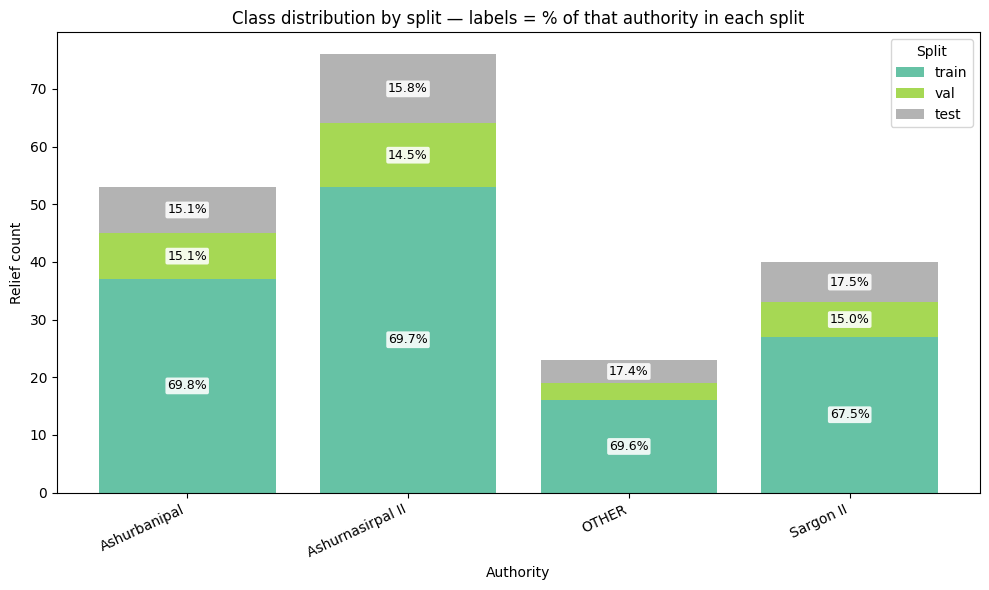

In [8]:
split_order = ["train", "val", "test"]
# Count unique reliefs per authority × split (splits are assigned per Relief_ID).
relief_df = df.drop_duplicates(subset=["Relief_ID"])
dist = relief_df.groupby(["Authority", "split"]).size().unstack(fill_value=0)
for c in split_order:
    if c not in dist.columns:
        dist[c] = 0
dist = dist[split_order]

pct_within_authority = dist.div(dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
categories = dist.index.astype(str)
x = np.arange(len(categories))
colors = plt.cm.Set2(np.linspace(0, 1, len(split_order)))
bottom = np.zeros(len(categories))
max_total = dist.sum(axis=1).max()

for i, split_name in enumerate(split_order):
    heights = dist[split_name].to_numpy()
    pcts = pct_within_authority[split_name].to_numpy()
    ax.bar(x, heights, bottom=bottom, label=split_name, color=colors[i])
    for j, (h, p) in enumerate(zip(heights, pcts)):
        if h <= 0 or h < 0.04 * max_total:
            continue
        ax.text(
            x[j],
            bottom[j] + h / 2,
            f"{p:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.88, edgecolor="none"),
        )
    bottom += heights

ax.set_xticks(x, categories, rotation=25, ha="right")
ax.set_xlabel("Authority")
ax.set_ylabel("Relief count")
ax.set_title("Class distribution by split — labels = % of that authority in each split")
ax.legend(title="Split")
fig.tight_layout()
plt.show()


# iamge level expansion

In [ ]:

records = []
unmatched_files = []
bad_format_files = []
bad_suffix_files = []

valid_suffixes = [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
pattern = re.compile(r"^(?P<relief_id>.+)-(?P<view_index>\d+)\.(?P<suffix>[A-Za-z0-9]+)$")

image_root = Path(config["data"]["local"]["dataset_root"])

for img_path in image_root.iterdir():
    if not img_path.is_file():
        continue

    suffix_lower = img_path.suffix.lower()
    if suffix_lower not in valid_suffixes:
        bad_suffix_files.append(img_path.name)
        continue


    match = pattern.match(img_path.name)
    if match is None:
        bad_format_files.append(img_path.name)
        continue

    relief_id = match.group("relief_id")
    view_index = int(match.group("view_index"))

    if relief_id not in df["Relief_ID"].values:
        unmatched_files.append(img_path.name)
        continue

    records.append({
        "Relief_ID": relief_id,
        "Authority": df[df["Relief_ID"] == relief_id]["Authority"].values[0],
        "split": df[df["Relief_ID"] == relief_id]["split"].values[0],
        "image_path": img_path,
        "view_index": view_index,
        "suffix": suffix_lower,
    })

image_df = pd.DataFrame(records)

assert not image_df.empty, "No matched image files were found."

missing_reliefs = set(df["Relief_ID"]) - set(image_df["Relief_ID"])

print(f"Matched images: {len(image_df)}")
print(f"Unique matched Relief_IDs: {image_df['Relief_ID'].nunique()}")
print(f"Reliefs with no matched local image files: {len(missing_reliefs)}")
print(f"The missing reliefs are: {missing_reliefs}")

print("\nImage-level split counts:")
print(image_df["split"].value_counts())

print("\nImage counts by class and split:")
print(pd.crosstab(image_df["split"], image_df["Authority"]))

if bad_format_files:
    print(f"\nFiles skipped due to bad filename format: {len(bad_format_files)}")
    print(bad_format_files[:20])

if unmatched_files:
    print(f"\nFiles skipped because Relief_ID not found in metadata: {len(unmatched_files)}")
    print(unmatched_files[:20])

if bad_suffix_files:
    print(f"\nFiles skipped due to unsupported suffix: {len(bad_suffix_files)}")
    print(bad_suffix_files[:20])

image_df = image_df.sort_values(["Relief_ID", "view_index"]).reset_index(drop=True)



Matched images: 696
Unique matched Relief_IDs: 189
Reliefs with no matched local image files: 3

Image-level split counts:
split
train    483
test     114
val       99
Name: count, dtype: int64

Image counts by class and split:
Authority  Ashurbanipal  Ashurnasirpal II  OTHER  Sargon II
split                                                      
test                 33                34     18         29
train               192               168     48         75
val                  44                32     14          9


In [12]:
output_image_table =_repo_root()/"data"/"image_level_dataset.csv"
image_df.to_csv(output_image_table, index=False)
print(f"\nSaved image-level dataset table to: {output_image_table}")


Saved image-level dataset table to: /home/kostya/projects/thesis-assyrian-relief/data/image_level_dataset.csv
